# Testing Models

In [5]:
import pandas as pd
from taxipred.utils.constants import NEW_CSV_PATH

df = pd.read_csv(NEW_CSV_PATH)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951 entries, 0 to 950
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_distance_km       901 non-null    float64
 1   time_of_day            902 non-null    object 
 2   day_of_week            905 non-null    object 
 3   traffic_conditions     901 non-null    object 
 4   weather                905 non-null    object 
 5   base_fare              907 non-null    float64
 6   per_km_rate            907 non-null    float64
 7   per_minute_rate        902 non-null    float64
 8   trip_duration_minutes  905 non-null    float64
 9   trip_price             951 non-null    float64
dtypes: float64(6), object(4)
memory usage: 74.4+ KB


## Separating features and target

Excluding Data Leakage Columns
- Why exclude base_fare, per_km_rate, and per_minute_rate?
    - These columns are **directly used in the price calculation formula**:
    - trip_price = base_fare + (trip_distance_km × per_km_rate) + (trip_duration_minutes × per_minute_rate)


In [6]:
leakage_columns = ["base_fare", "per_km_rate", "per_minute_rate"]

X = df.drop(columns=["trip_price"] + leakage_columns)
y = df["trip_price"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nExcluded columns (data leakage): {leakage_columns}")
print(f"\nIncluded features: {list(X.columns)}")

Features shape: (951, 6)
Target shape: (951,)

Excluded columns (data leakage): ['base_fare', 'per_km_rate', 'per_minute_rate']

Included features: ['trip_distance_km', 'time_of_day', 'day_of_week', 'traffic_conditions', 'weather', 'trip_duration_minutes']


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Winsorization (Outlier Handling)

**Why after train/test split?**
- Winsorization uses statistics (Q1, Q3, IQR) calculated from the data
- If we calculate these statistics on the entire dataset (including test set), information from the test set leaks into the training process
- **Best practice**: Calculate the threshold on training data only, then apply it to both train and test sets

This ensures the model only learns from training data patterns, making evaluation more realistic.

In [9]:
y_train

181    76.1018
274    34.2597
850    56.3682
69     92.8432
291    19.9412
        ...   
106    99.8038
270     8.9203
860    31.6941
435    55.8212
102    66.2817
Name: trip_price, Length: 637, dtype: float64

Text(0.5, 1.0, 'Original Distribution of Trip Price (y_test)')

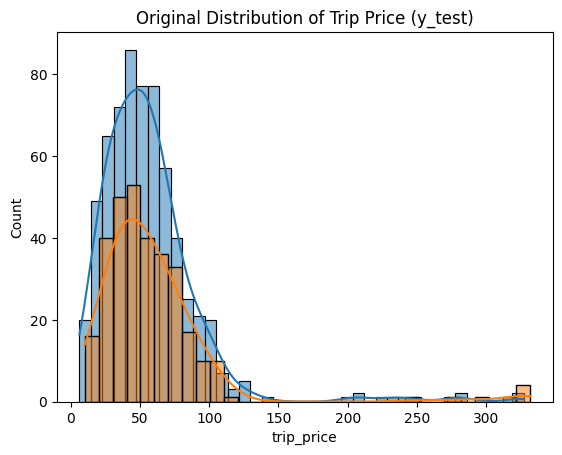

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt 

sns.histplot(y_train, kde=True)
plt.title("Original Distribution of Trip Price (y_train)")

sns.histplot(y_test, kde=True)
plt.title("Original Distribution of Trip Price (y_test)")

In [11]:
# Calculate winsorization threshold on TRAINING data only
Q3_train = y_train.quantile(0.75)
Q1_train = y_train.quantile(0.25)
IQR_train = Q3_train - Q1_train
upper_threshold = Q3_train + 1.5 * IQR_train

print(f"Winsorization threshold (calculated on training data): {upper_threshold:.2f}")

# Apply the threshold to both train and test sets
y_train_winsorized = y_train.clip(upper=upper_threshold)
y_test_winsorized = y_test.clip(upper=upper_threshold)

print(f"\nOriginal y_train max: {y_train.max():.2f}")
print(f"Winsorized y_train max: {y_train_winsorized.max():.2f}")
print(f"\nOriginal y_test max: {y_test.max():.2f}")
print(f"Winsorized y_test max: {y_test_winsorized.max():.2f}")

# Update y_train and y_test for use in modeling
y_train = y_train_winsorized
y_test = y_test_winsorized

Winsorization threshold (calculated on training data): 121.58

Original y_train max: 327.22
Winsorized y_train max: 121.58

Original y_test max: 332.04
Winsorized y_test max: 121.58


Text(0.5, 1.0, 'Winstorized Distribution of Trip Price (y_test)')

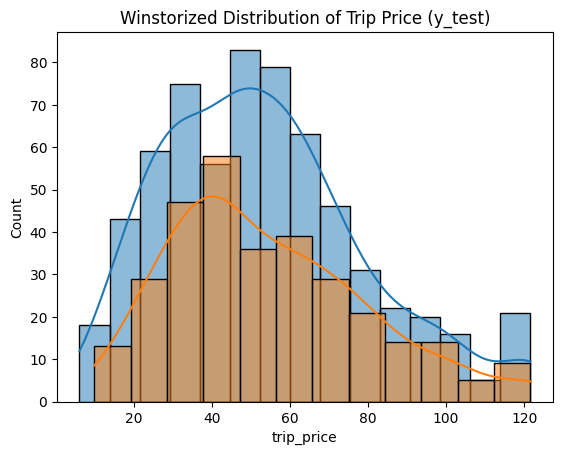

In [ ]:
sns.histplot(y_train, kde=True)
plt.title("Winsorized Distribution of Trip Price (y_train)")

sns.histplot(y_test, kde=True)
plt.title("Winsorized Distribution of Trip Price (y_test)")

## Imputation

- Imputing the NaN values with best performing methods based on our evaluations.

In [4]:
numeric_columns = X_train.select_dtypes(include=["number"]).columns
cat_columns = X_train.select_dtypes(include=["object"]).columns

numeric_columns, cat_columns

(Index(['trip_distance_km', 'base_fare', 'per_km_rate', 'per_minute_rate',
        'trip_duration_minutes'],
       dtype='object'),
 Index(['time_of_day', 'day_of_week', 'traffic_conditions', 'weather'], dtype='object'))

### Numerical Columns
- Using MICE (Multiple Imputation by Chained Equations) to impute null values for numerical columns the performance on our actual data.

In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import LinearRegression

X_train_num_imp = X_train[numeric_columns].copy()

mice_imputer = IterativeImputer(
    estimator=LinearRegression(),
    random_state=42,
    max_iter=20,
    sample_posterior=False
)

X_train_num_imp = pd.DataFrame(
    mice_imputer.fit_transform(X_train_num_imp),
    columns=X_train_num_imp.columns,
    index=X_train_num_imp.index
)

X_train_num_imp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 637 entries, 181 to 102
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_distance_km       637 non-null    float64
 1   base_fare              637 non-null    float64
 2   per_km_rate            637 non-null    float64
 3   per_minute_rate        637 non-null    float64
 4   trip_duration_minutes  637 non-null    float64
dtypes: float64(5)
memory usage: 29.9 KB


In [6]:
X_test_num_imp = X_test[numeric_columns].copy()
X_test_num_imp = pd.DataFrame(
    mice_imputer.transform(X_test[numeric_columns]),
    columns=numeric_columns,
    index=X_test.index
)

In [7]:
X_train_num_imp.info(), X_test_num_imp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 637 entries, 181 to 102
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_distance_km       637 non-null    float64
 1   base_fare              637 non-null    float64
 2   per_km_rate            637 non-null    float64
 3   per_minute_rate        637 non-null    float64
 4   trip_duration_minutes  637 non-null    float64
dtypes: float64(5)
memory usage: 29.9 KB
<class 'pandas.core.frame.DataFrame'>
Index: 314 entries, 199 to 891
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_distance_km       314 non-null    float64
 1   base_fare              314 non-null    float64
 2   per_km_rate            314 non-null    float64
 3   per_minute_rate        314 non-null    float64
 4   trip_duration_minutes  314 non-null    float64
dtypes: float64(5)
memory usa

(None, None)

### Categorical Columns
- Most-frequent imputation will be used for categorical variables because it provides stable and consistently strong performance across categories while avoiding unnecessary model complexity

In [8]:
X_train_cat_imp = X_train[cat_columns].copy()
X_test_cat_imp = X_test[cat_columns].copy()

In [9]:
cat_imputer = SimpleImputer(strategy="most_frequent")


X_train_cat_imp = pd.DataFrame(
    cat_imputer.fit_transform(X_train_cat_imp),
    columns=cat_columns,
    index=X_train.index
)


In [10]:
X_test_cat_imp = pd.DataFrame(
    cat_imputer.transform(X_test_cat_imp),
    columns=cat_columns,
    index=X_test.index
)

In [11]:
# Combine imputed numerical and categorical columns back together
X_train_imputed = pd.concat([X_train_num_imp, X_train_cat_imp], axis=1)
X_test_imputed = pd.concat([X_test_num_imp, X_test_cat_imp], axis=1)

# Ensure columns are in the same order as original
X_train_imputed = X_train_imputed[X_train.columns]
X_test_imputed = X_test_imputed[X_test.columns]

# Verify no missing values
print("Missing values in X_train_imputed:", X_train_imputed.isna().sum().sum())
print("Missing values in X_test_imputed:", X_test_imputed.isna().sum().sum())
X_train_imputed.info()

Missing values in X_train_imputed: 0
Missing values in X_test_imputed: 0
<class 'pandas.core.frame.DataFrame'>
Index: 637 entries, 181 to 102
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_distance_km       637 non-null    float64
 1   time_of_day            637 non-null    object 
 2   day_of_week            637 non-null    object 
 3   traffic_conditions     637 non-null    object 
 4   weather                637 non-null    object 
 5   base_fare              637 non-null    float64
 6   per_km_rate            637 non-null    float64
 7   per_minute_rate        637 non-null    float64
 8   trip_duration_minutes  637 non-null    float64
dtypes: float64(5), object(4)
memory usage: 49.8+ KB
